In [30]:
from dotenv import load_dotenv
import os
import kagglehub
import kagglehub
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, auc
from xgboost import XGBClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt


Setup (excluding the millions of imports above, bc its python)

In [4]:
#This is a token check, you will need your own kaggle api token, refer to the README (if I remember to make one lol!)
load_dotenv('kaggletoken.env')
token = os.getenv('KAGGLE_API_TOKEN')

if not token:
    raise RuntimeError("KAGGLE_API_TOKEN not found — check kaggletoken.env")
os.environ['KAGGLE_API_TOKEN'] = token

Dataset prep

In [5]:
path = kagglehub.competition_download('home-credit-default-risk')
csv_path = path + r"/application_train.csv"

df = pd.read_csv(csv_path)

You dont have to do this, but I do this js to kinda see what im working with

In [6]:
print(df.head())
print(df.shape)
print(df.dtypes.value_counts())
pd.set_option('display.max_columns', None)
print(df.columns.tolist())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

This one is an actual real world dataset, so its gonna be a little messy

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64


Turns out some of our data is missing! We will drop some of these (because they dont matter as much anyways) but we will need the exit sources

In [9]:
# Step 2: drop high-missing columns (keep EXT_SOURCE_1)
threshold = 40
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
if 'EXT_SOURCE_1' in cols_to_drop:
    cols_to_drop.remove('EXT_SOURCE_1')
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns")

Dropped 48 columns


Ok so this compeition is old, there's a huge anomaly here in the DAYS_EMPLOYED columns (I looked it up on Google btw lol)

In [10]:
df['DAYS_EMPLOYED_ANOM'] = df['DAYS_EMPLOYED'] == 365243
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

Finally our X and Y loll

In [19]:
y = df['TARGET']
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
categorical_cols = X_train.select_dtypes(include='str').columns.tolist()
numerical_cols = X_train.select_dtypes(include='number').columns.tolist()

In [21]:
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', categorical_pipe, categorical_cols),
    ('num', numeric_pipe, numerical_cols)
])

In [22]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

We're gonna use two models to compare, XGBoost (which I use a lot) and a new one im trying out which is LightGBM (from Microsoft!)

In [27]:
#XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    random_state=42,
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight
)
model.fit(X_train_preprocessed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [28]:
#LightGBM
model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
model_lgb.fit(X_train_preprocessed, y_train)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3567
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 173
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Ok lets evaluate these models

In [29]:

xgb_probs = model.predict_proba(X_test_preprocessed)[:, 1]
lgb_probs = model_lgb.predict_proba(X_test_preprocessed)[:, 1]


xgb_roc_auc = roc_auc_score(y_test, xgb_probs)
lgb_roc_auc = roc_auc_score(y_test, lgb_probs)

xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_probs)
lgb_precision, lgb_recall, _ = precision_recall_curve(y_test, lgb_probs)

xgb_pr_auc = auc(xgb_recall, xgb_precision)
lgb_pr_auc = auc(lgb_recall, lgb_precision)

print(f"XGBoost  — ROC-AUC: {xgb_roc_auc:.4f} | PR-AUC: {xgb_pr_auc:.4f}")
print(f"LightGBM — ROC-AUC: {lgb_roc_auc:.4f} | PR-AUC: {lgb_pr_auc:.4f}")

XGBoost  — ROC-AUC: 0.7308 | PR-AUC: 0.2171
LightGBM — ROC-AUC: 0.7599 | PR-AUC: 0.2474


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ok time to actually show what's happening

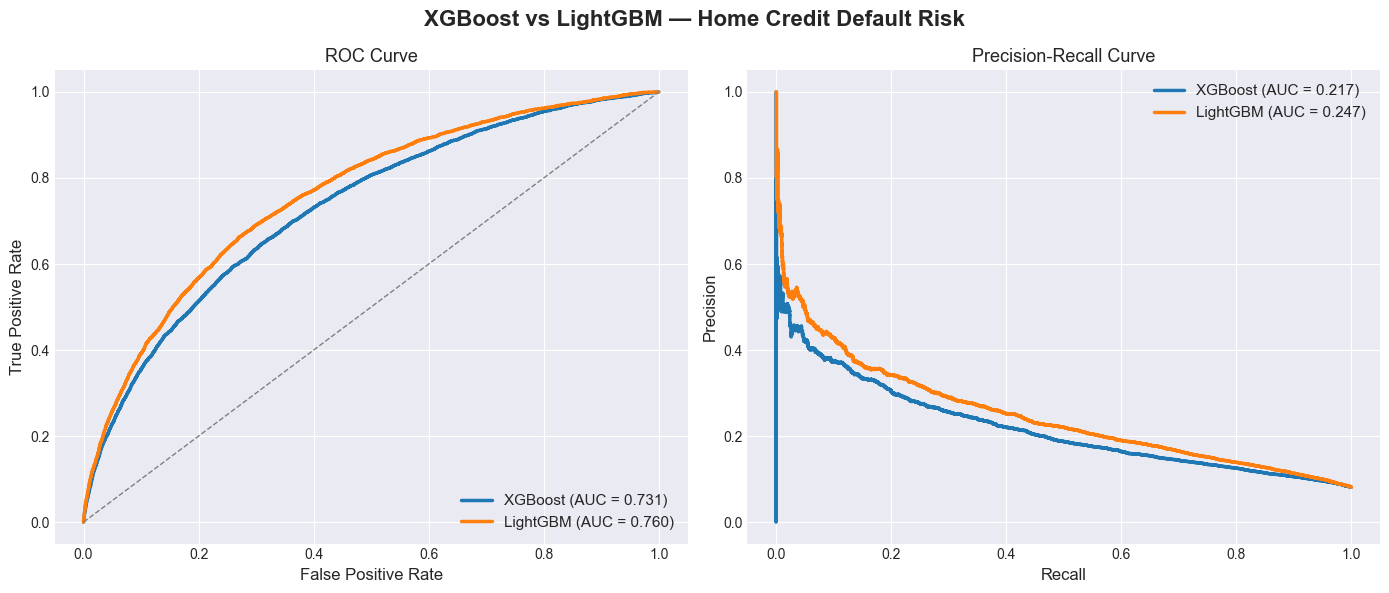

In [31]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('XGBoost vs LightGBM — Home Credit Default Risk', fontsize=16, fontweight='bold')

# ROC curve
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_probs)

axes[0].plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_roc_auc:.3f})', linewidth=2.5)
axes[0].plot(lgb_fpr, lgb_tpr, label=f'LightGBM (AUC = {lgb_roc_auc:.3f})', linewidth=2.5)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend(loc='lower right', fontsize=11)

# Precision-Recall curve
axes[1].plot(xgb_recall, xgb_precision, label=f'XGBoost (AUC = {xgb_pr_auc:.3f})', linewidth=2.5)
axes[1].plot(lgb_recall, lgb_precision, label=f'LightGBM (AUC = {lgb_pr_auc:.3f})', linewidth=2.5)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()